<b>Group Number:</b>
<br><b>Name Group Member 1:</b>
<br><b>u-Kürzel Group Member 1:</b>
<br><b>Name Group Member 2:</b>
<br><b>u-Kürzel Group Member 2:</b>

# Unit 3: Data Visualization4

## Introduction

In Unit 1, we performed initial Exploratory Data Analysis (EDA) including some basic visualizations. In Unit 2, we cleaned the data, encoded categorical features, and scaled numerical features, resulting in processed data (`X_processed`, `y_processed`) ready for modeling.

This unit focuses on **Data Visualization** applied *after* these preprocessing steps. Visualizations help us:
1.  Confirm the effects of our preprocessing (e.g., scaling).
2.  Gain deeper insights into the relationships between features and the target variable in the *prepared* data.
3.  Identify patterns or separations between classes that might be useful for modeling.
4.  Communicate findings effectively.

We will use libraries like `matplotlib` and `seaborn` to create various plots based on the processed data, while sometimes referring back to the original data for interpreting categorical relationships.

In [2]:
import pandas as pd  # https://pandas.pydata.org/docs/
import numpy as np  # https://numpy.org/doc/2.1/
import matplotlib.pyplot as plt  # https://matplotlib.org/stable/users/index.html
import seaborn as sns  # https://seaborn.pydata.org/
from sklearn.decomposition import (
    PCA,
)  # https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html This is used for dimensionality reduction

# Configure visualization styles
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 7)

# --- Load Processed Data (Saved from Unit 2) ---
X_processed = None
y_processed = None
data_loaded = False
try:
    # Adjust paths if necessary based on where you saved them
    X_processed = np.load("data/bank_X_processed.npy", allow_pickle=True)
    y_processed = np.load("data/bank_y_processed.npy", allow_pickle=True)
    print("Successfully loaded processed data (X_processed, y_processed).")
    print(f"X_processed shape: {X_processed.shape}")
    print(f"y_processed shape: {y_processed.shape}")
    data_loaded = True
except FileNotFoundError:
    print(
        "Error: Processed data files ('bank_X_processed.npy', 'bank_y_processed.npy') not found."
    )
    print("Please ensure Unit 2 was run successfully and saved the data.")
except Exception as e:
    print(f"An error occurred loading processed data: {e}")

# --- Also Load Original Data for Contextual Plots ---
filename_original = "data/bank.csv"
bank_df_original = None
original_numeric_cols = []
original_categorical_cols = []
feature_names_processed = []

bank_df_original = pd.read_csv(filename_original, sep=";")
# Drop duration right away as it was removed in processing
if "duration" in bank_df_original.columns:
    bank_df_original = bank_df_original.drop("duration", axis=1)

original_numerical_cols = bank_df_original.select_dtypes(
    include=np.number
).columns.tolist()
original_categorical_cols = bank_df_original.select_dtypes(
    include="object"
).columns.tolist()
if "y" in original_categorical_cols:
    original_categorical_cols.remove("y")

# the dummy function will create four classes, one per column which containes unknown in itself. Therefore, we must initially remove them,
# to ensure we get exact index matches.
print("\nApplying imputation fix to reconstruct feature names correctly! Read the comment above this print-out")
temp_df_for_cols = bank_df_original.copy()
# These are the columns that contained 'unknown' values in Unit 2
cols_with_unknown = ['job', 'education', 'contact', 'poutcome']

for col in cols_with_unknown:
    if 'unknown' in temp_df_for_cols[col].unique():
        # Simple mode imputation as performed in Unit 2
        mode_val = temp_df_for_cols[col].mode()[0]
        if mode_val == 'unknown':  # Handle edge case where mode is 'unknown'
            mode_val = temp_df_for_cols[col].value_counts().index[1]
        temp_df_for_cols[col] = temp_df_for_cols[col].replace(
            'unknown', mode_val)

# Now, create dummy columns from the *fixed* temporary DataFrame
temp_encoded_df = pd.get_dummies(
    temp_df_for_cols.drop("y", axis=1),
    columns=original_categorical_cols,
    drop_first=True,
)
feature_names_processed = temp_encoded_df.columns.tolist()
print("Fix applied. Feature names should now match X_processed.")


print(
    f"\nSuccessfully loaded original data from {filename_original} for context.")
print(
    f"Total processed feature names generated: {len(feature_names_processed)}")
if data_loaded and len(feature_names_processed) != X_processed.shape[1]:
    print(
        f"Warning: Mismatch between generated feature names ({len(feature_names_processed)}) and X_processed columns ({X_processed.shape[1]}). Indexing might be incorrect."
    )
else:
    print("Feature name count matches X_processed columns. No warning.")

Successfully loaded processed data (X_processed, y_processed).
X_processed shape: (4521, 50)
y_processed shape: (4521,)

Applying imputation fix to reconstruct feature names correctly! Read the comment above this print-out
Fix applied. Feature names should now match X_processed.

Successfully loaded original data from data/bank.csv for context.
Total processed feature names generated: 37


## 3.1 Visualizing Preprocessing Effects

As a quick sanity check, let's visualise the effect of the Standardization applied in Unit 2. We transformed numerical features to have a mean near 0 and a standard deviation near 1. Comparing the distribution shape before and after scaling can confirm this. We'll use the 'balance' feature as an example, as it likely had a wide range initially.

--- Visualizing Scaling Effect on 'balance' ---


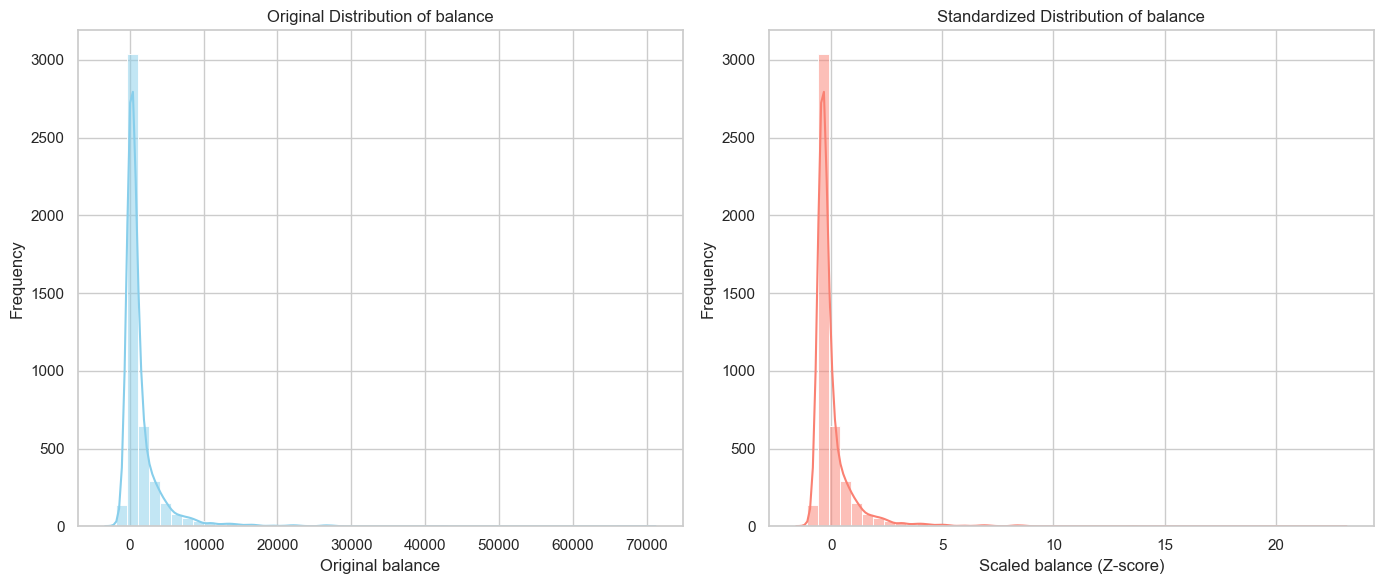

Now the mean is 0.00 and the std is 1.00.

Whereas before it was 1422.66 and the std was 3009.64.



In [3]:
feature_to_compare = (
    "balance"  # You can change this to any feature you want to visualize
)
print(f"--- Visualizing Scaling Effect on '{feature_to_compare}' ---")

scaled_feature_index = feature_names_processed.index(feature_to_compare)

plt.figure(figsize=(14, 6))

# Plot original distribution
plt.subplot(1, 2, 1)
sns.histplot(bank_df_original[feature_to_compare], kde=True, color="skyblue", bins=50)
plt.title(f"Original Distribution of {feature_to_compare}")
plt.xlabel(f"Original {feature_to_compare}")
plt.ylabel("Frequency")

# Plot scaled distribution
plt.subplot(1, 2, 2)
sns.histplot(X_processed[:, scaled_feature_index], kde=True, color="salmon", bins=50)
plt.title(f"Standardized Distribution of {feature_to_compare}")
plt.xlabel(f"Scaled {feature_to_compare} (Z-score)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()
print(f"Now the mean is {X_processed[:, scaled_feature_index].mean():.2f} and the std is {X_processed[:, scaled_feature_index].std():.2f}.\n")
print(f"Whereas before it was {bank_df_original[feature_to_compare].mean():.2f} and the std was {bank_df_original[feature_to_compare].std():.2f}.\n")

## 3.2 Visualizing Processed Numerical Features vs. Target

A key goal of EDA is to understand which features might help distinguish between the target classes (subscribers vs. non-subscribers). We can investigate this by comparing the distributions of our *scaled* numerical features for each target class (`y=0` vs `y=1`).

**Box plots** are excellent for this. They visualise the median (centre line), interquartile range (IQR, the box), and potential outliers (points beyond the whiskers). By placing the box plots for each class side-by-side for a given feature, we can easily compare their central tendency and spread. Significant differences in the boxes' positions or sizes suggest the feature has discriminatory power.

<div class="alert alert-block alert-info">
    <b>Reading Box Plots:</b>
    <ul>
        <li>The line inside the box is the median (50th percentile).</li>
        <li>The bottom and top edges of the box are the 1st quartile (Q1, 25th percentile) and 3rd quartile (Q3, 75th percentile).</li>
        <li>The whiskers typically extend to 1.5 times the IQR from the box edges, or to the data extremes if they fall within that range.</li>
        <li>Points outside the whiskers are often flagged as potential outliers.</li>
        <li>Comparing plots: Look for differences in median position, box height (IQR/spread), and whisker length between the target classes.</li>
        <li><a href="https://www.simplypsychology.org/boxplots.html" target="_blank">Simply Psychology: Understanding Box Plots</a></li>
    </ul>
</div>

<div class="alert alert-block alert-success">
<b>Task 3.1: Numerical Features vs. Target (2 pts)</b>

<ul>
    <li> Select a few key *original* numerical feature names (e.g., 'age', 'balance', 'campaign').</li>
    <li> For each selected feature:
        <ol>
            <li>Find its corresponding column index in the `X_processed` matrix (using the `feature_names_processed` list).</li>
            <li>Create a box plot comparing the distribution of this *scaled* feature for each target class (y=0 and y=1).</li>
        </ol>
    </li>
    <li> Ensure plots have clear titles and labels (indicating the feature and that it's scaled).</li>
</ul>
</div>


--- Visualizing Scaled Numerical Features vs. Target ---


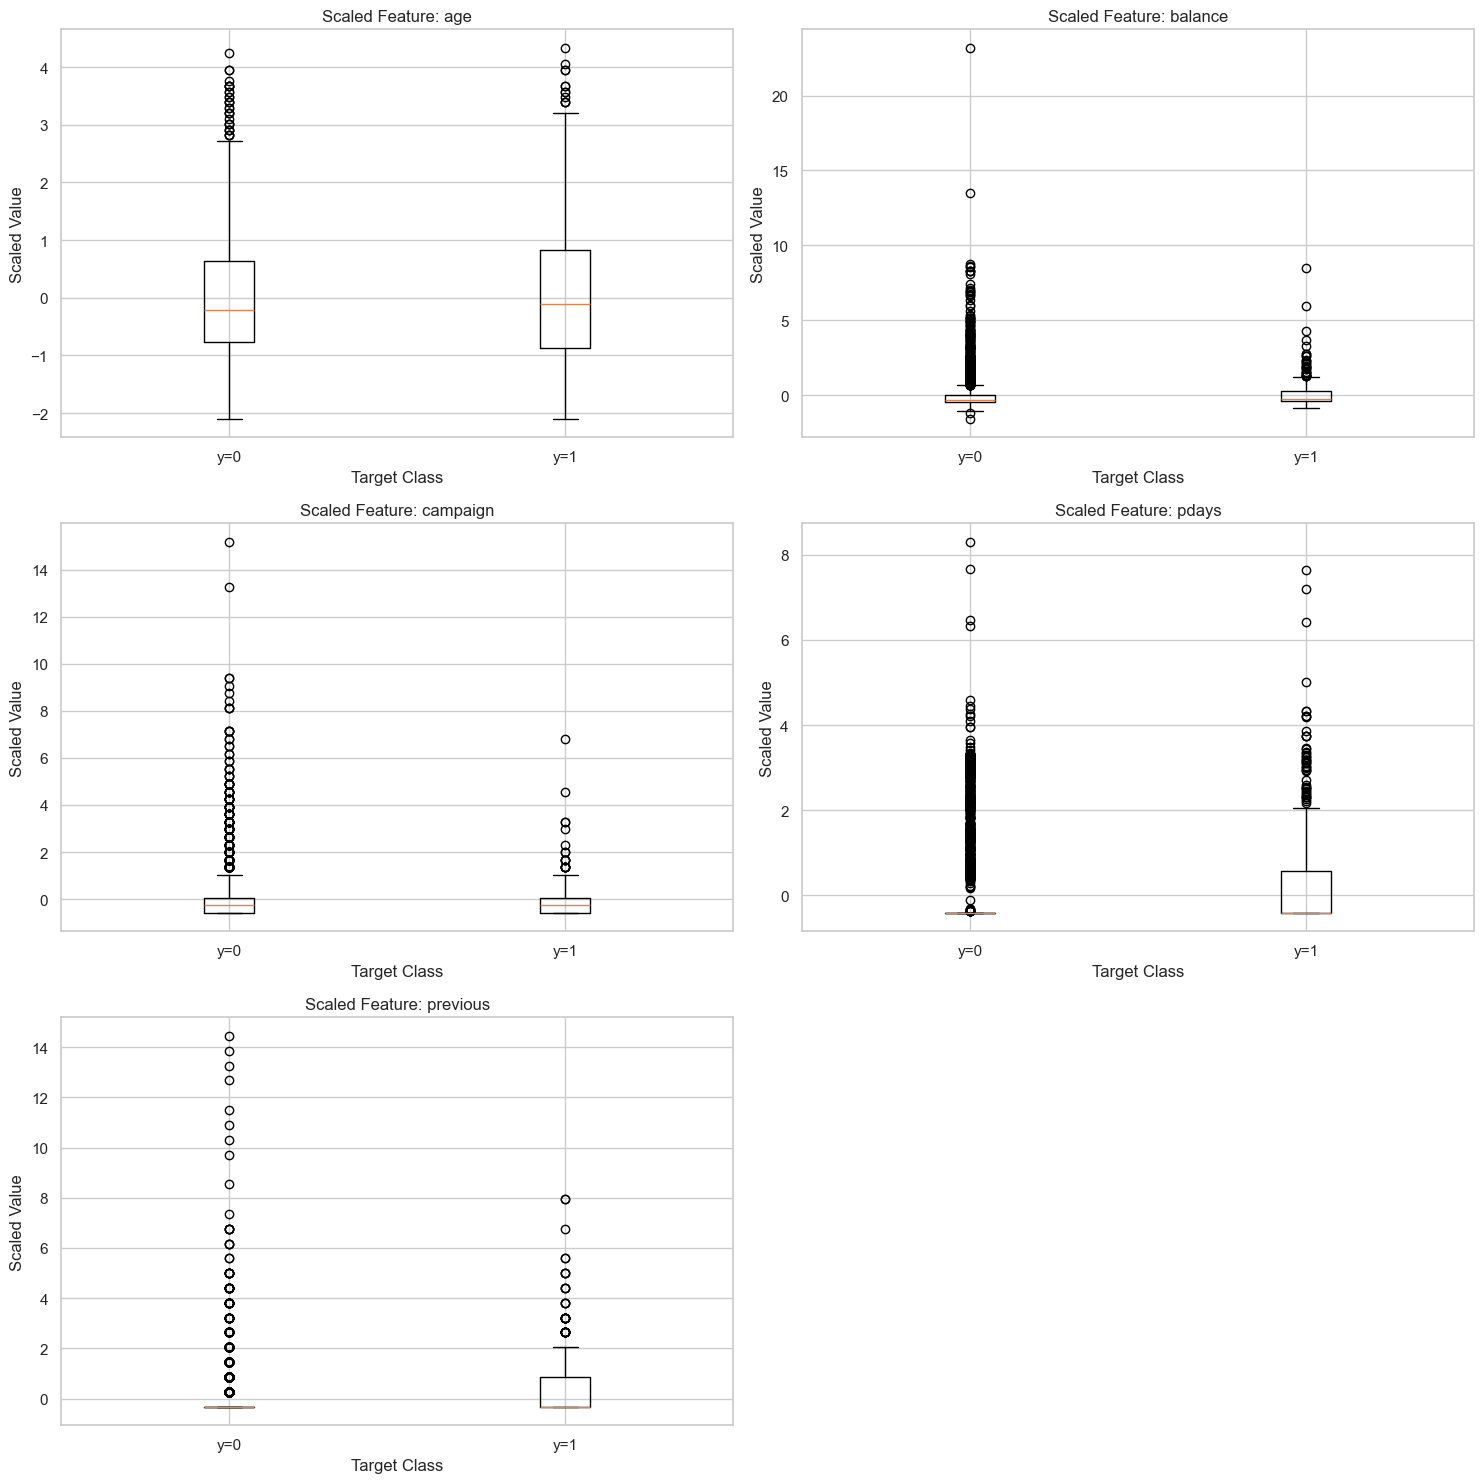

In [4]:
print("\n--- Visualizing Scaled Numerical Features vs. Target ---")

numerical_features_to_plot_vs_target = [
    "age",
    "balance",
    "campaign",
    "pdays",
    "previous",
]

plt.figure(figsize=(15, 5 * ((len(numerical_features_to_plot_vs_target) + 1) // 2)))

plot_index = 1
### STUDENT CODE HERE (2 pts)
for feature in numerical_features_to_plot_vs_target:
    if feature in feature_names_processed:
        feature_index = feature_names_processed.index(feature)

        plt.subplot((len(numerical_features_to_plot_vs_target) + 1) // 2, 2, plot_index)

        # Use y_processed instead of y
        feature_values_y0 = X_processed[y_processed == 0, feature_index]
        feature_values_y1 = X_processed[y_processed == 1, feature_index]

        plt.boxplot([feature_values_y0, feature_values_y1], tick_labels=["y=0", "y=1"])
        plt.title(f"Scaled Feature: {feature}")
        plt.xlabel("Target Class")
        plt.ylabel("Scaled Value")
        

        plot_index += 1            
### STUDENT CODE until HERE 
plt.tight_layout()
plt.show()

## 3.3 Visualizing Original Categorical Features vs. Target

While we One-Hot Encoded categorical features for modelling, understanding their relationship with the target variable ('y') is often more intuitive using the *original* categories. A common way to do this is to visualise the **subscription rate** (i.e., the proportion of 'yes' outcomes) within each category of a given feature.

For example, we can calculate the percentage of clients who subscribed for each 'job' type, or for each 'marital' status. If these rates vary significantly across categories, the feature is likely predictive. Bar plots are suitable for displaying these rates.

<div class="alert alert-block alert-success">
<b>Task 3.2: Categorical Features vs. Target (2 pts)</b>

<ul>
    <li> Select a few key *original* categorical feature names (e.g., 'job', 'marital', 'contact', 'poutcome').</li>
    <li> For each selected feature:
        <ol>
            <li>Use the `bank_df_original` DataFrame (which contains original categories and the original 'y' column).</li>
            <li>Calculate the subscription rate ('yes' proportion) for each category within the feature.</li>
            <li>Create a bar plot showing these subscription rates per category.</li>
        </ol>
    </li>
    <li> Ensure plots have clear titles and labels.</li>
</ul>
<i>Hint: You might group the original DataFrame by the categorical feature and calculate the mean of the numerically encoded target (where 'yes'=1, 'no'=0) within each group, then plot the results. Or use seaborn's `barplot` with `estimator=mean` if 'y' is encoded numerically.</i>
</div>


--- Visualizing Original Categorical Features vs. Target Subscription Rate ---


<Figure size 1200x4200 with 0 Axes>

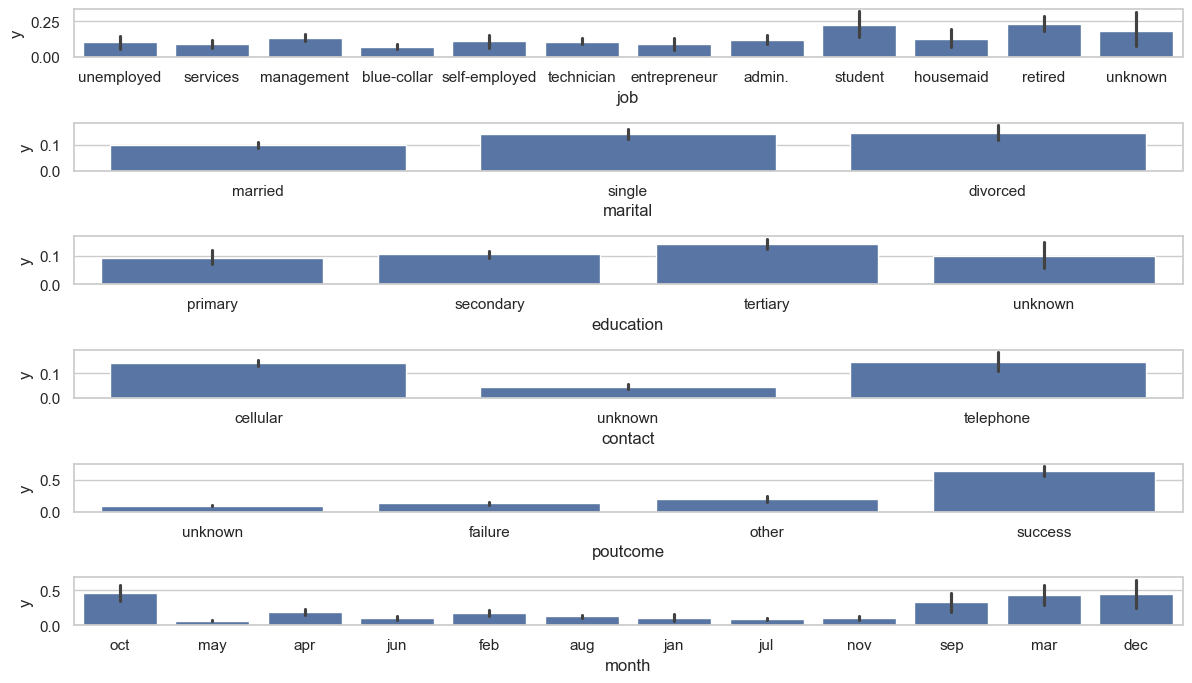

In [5]:
print(
    "\n--- Visualizing Original Categorical Features vs. Target Subscription Rate ---"
)

# Ensure target 'y' is numerically encoded (0/1) in the original df copy for easy mean calculation
bank_df_original["y_numeric"] = bank_df_original["y"].map({"yes": 1, "no": 0})

categorical_features_to_plot_vs_target = [
    "job",
    "marital",
    "education",
    "contact",
    "poutcome",
    "month",
]

plt.figure(
    figsize=(12, 7 * len(categorical_features_to_plot_vs_target))
)  # Adjust figure size

plot_index = 1
### STUDENT CODE HERE (2 pts) 
plot_index = 0
fig, axs = plt.subplots(nrows = len(categorical_features_to_plot_vs_target), ncols = 1)
mapping_dict = {
    "yes" : 1,
    "no" : 0
}
y_numerical = bank_df_original['y'].map(mapping_dict)

for feature in categorical_features_to_plot_vs_target:
    sns.barplot(data = bank_df_original, x = feature, y= y_numerical, ax = axs[plot_index], legend='auto')
    plot_index += 1


### STUDENT CODE until HERE 
plt.tight_layout()
plt.show()

## 3.4 Correlation Heatmap (Processed Numerical Features)

Let's briefly revisit the correlation heatmap, this time specifically selecting the *scaled* numerical columns from our `X_processed` matrix. While scaling itself doesn't alter Pearson correlation coefficients (as it's a linear transformation), generating this plot confirms we can correctly identify and extract these processed numerical columns for analysis. It should look identical to the numerical part of the heatmap generated in Unit 1, just potentially with different column ordering if OHE was involved before scaling.


--- Correlation Heatmap (Scaled Numerical Features) ---


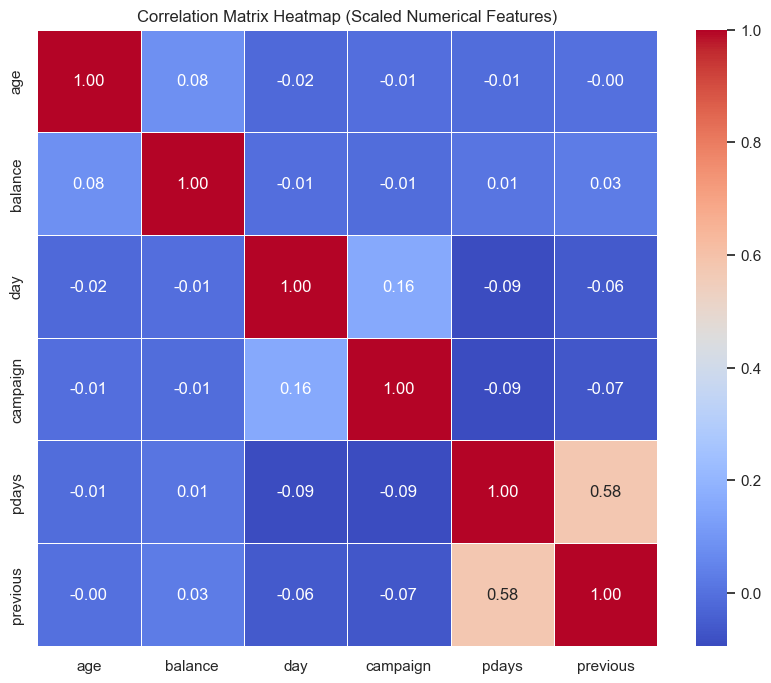

In [6]:
print("\n--- Correlation Heatmap (Scaled Numerical Features) ---")

# Find the indices of the original numerical columns within X_processed
numerical_indices = []
numerical_names_in_processed = []
for i, name in enumerate(feature_names_processed):
    # Check if the feature name corresponds to one of the original numerical columns
    # This is a simple check; more robust would be to track indices during preprocessing
    if name in original_numerical_cols:
        numerical_indices.append(i)
        numerical_names_in_processed.append(name)

if numerical_indices:
    # Select only the scaled numerical columns from X_processed
    X_processed_numerical = X_processed[:, numerical_indices]

    # Create a DataFrame for calculating correlation (needs column names)
    processed_numerical_df = pd.DataFrame(
        X_processed_numerical, columns=numerical_names_in_processed
    )

    # Calculate the correlation matrix
    correlation_matrix_processed = processed_numerical_df.corr()

    # Visualize the heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        correlation_matrix_processed,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
    )
    plt.title("Correlation Matrix Heatmap (Scaled Numerical Features)")
    plt.show()
else:
    print("Could not identify numerical columns in processed data for heatmap.")

## 3.5 Dimensionality Reduction Visualization

Our processed feature matrix `X_processed` has quite a few dimensions, especially after One-Hot Encoding. Visualising high-dimensional data directly is impossible. Techniques like **Principal Component Analysis (PCA)** or **t-Distributed Stochastic Neighbour Embedding (t-SNE)** can help by reducing the data to just 2 or 3 dimensions while trying to preserve some aspects of the original data structure. This allows us to create scatter plots and visually inspect if the target classes show any separation in the reduced space.

*   **PCA:** A linear technique that finds orthogonal axes (principal components) that capture the maximum variance in the data. Good for identifying broad, linear structures.
*   **t-SNE:** A non-linear technique particularly effective at revealing local structure and clusters. It focuses on keeping similar points close together in the low-dimensional map. Computationally more intensive than PCA and results can vary between runs. An example for its use can be seen on page 6 of this [paper](https://www.alphaxiv.org/abs/2312.13277v2), highlighting that the model spatially separates different concepts in its latent representation.

*Note: We use these mainly for **visual exploration**. While the resulting components can sometimes be used as features themselves, that's a separate modelling decision.*

<div class="alert alert-block alert-info">
    <b>Further Reading on Dimensionality Reduction:</b>
    <ul>
        <li><a href="https://scikit-learn.org/stable/modules/decomposition.html#pca" target="_blank">Scikit-learn: PCA Documentation</a></li>
        <li><a href="https://scikit-learn.org/stable/modules/manifold.html#t-sne" target="_blank">Scikit-learn: t-SNE Documentation</a></li>
        <li><a href="https://distill.pub/2016/misread-tsne/" target="_blank">Distill Pub: How to Use t-SNE Effectively (Excellent visual explanations)</a></li>
    </ul>
</div>


--- Dimensionality Reduction Visualization (PCA) ---
Explained variance ratio by 2 components: 0.290


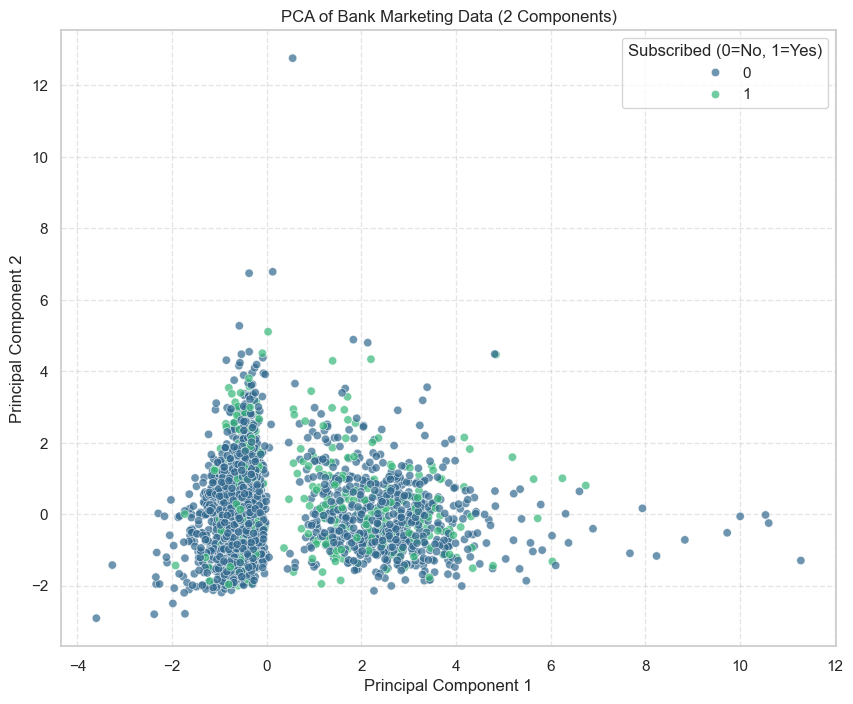

In [7]:
print("\n--- Dimensionality Reduction Visualization (PCA) ---")
# Apply PCA to reduce X_processed to 2 components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_processed)

print(
    f"Explained variance ratio by 2 components: {pca.explained_variance_ratio_.sum():.3f}"
)

# Create a DataFrame for plotting
pca_df = pd.DataFrame(
    data=X_pca, columns=["Principal Component 1", "Principal Component 2"]
)
pca_df["Target"] = y_processed

# Create scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x="Principal Component 1",
    y="Principal Component 2",
    hue="Target",
    palette="viridis",
    data=pca_df,
    alpha=0.7,
)
plt.title("PCA of Bank Marketing Data (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Subscribed (0=No, 1=Yes)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Unit 3 Summary & Deep Dive

In this unit, we focused on visualising the Bank Marketing dataset *after* cleaning and preprocessing. We examined the impact of scaling, compared the distributions of scaled numerical features across target classes using box plots, and analysed the relationship between original categorical features and the subscription rate using bar plots. We also revisited the correlation heatmap with scaled data and optionally visualised the data in 2D using PCA.


These visualisations help confirm our preprocessing steps and provide deeper insights into feature relationships and potential predictive patterns before moving to model training and evaluation.

### Deep Dive Topics

#### 1. Advanced Visualization Libraries: Interactive Plots with Plotly

Libraries like `matplotlib` and `seaborn` are excellent for static plots. However, libraries like `Plotly` enable the creation of interactive visualisations directly within the notebook or as standalone HTML files. This allows for zooming, panning, hovering to see data values, and selecting/deselecting traces, which can significantly enhance exploratory analysis.

`plotly.express` is a high-level interface to Plotly that makes creating common plots very straightforward, similar to seaborn. Let's recreate the PCA scatter plot using Plotly Express.

In [8]:
# Deep Dive 1: Plotly Demo
import plotly.express as px
import pandas as pd

print("\n--- Deep Dive: Interactive PCA Plot with Plotly Express ---")

if bank_df_original is not None and len(pca_df) == len(bank_df_original):
    pca_df["Target_Label"] = bank_df_original["y"].values
else:
    pca_df["Target_Label"] = pca_df["Target"].map({0: "No", 1: "Yes"})

fig = px.scatter(
    pca_df,
    x="Principal Component 1",
    y="Principal Component 2",
    color="Target_Label",
    title="Interactive PCA of Bank Marketing Data (Plotly), feel free to zoom in!",
    labels={"Target_Label": "Subscribed"},
    hover_data=pca_df.columns,
)

fig.update_layout(
    legend_title_text="Subscribed",
    xaxis_title="Principal Component 1",
    yaxis_title="Principal Component 2",
)
fig.update_traces(marker=dict(size=8, opacity=0.7))

fig.show()


--- Deep Dive: Interactive PCA Plot with Plotly Express ---


*Interact with the plot above! You can zoom, pan, and hover over points to see their component values.*

#### 2. Visualizing High-Dimensional Data: Parallel Coordinates

When you have more than 2 or 3 numerical features, visualising their relationships simultaneously becomes challenging. Scatter plot matrices (`seaborn.pairplot`) can help but become cluttered with many features. **Parallel Coordinates plots** offer an alternative way to visualise multivariate data.

Each vertical line represents a feature (axis), scaled typically to a common range (like 0-1 or standardised). Each sample (row) in the dataset is represented as a polyline that connects the corresponding values across all the feature axes. Lines are often coloured by the target class. This can help reveal patterns, clusters, and correlations between adjacent axes based on how lines flow. For example, if lines for one class consistently go 'up' between axis A and B while lines for another class go 'down', it suggests an interaction relevant to class separation.

Let's create one using a subset of our *scaled* numerical features.

*Plotly also has good support for parallel coordinates (`plotly.graph_objects.Parcoords` or `plotly.express.parallel_coordinates`). Pandas also has a built-in version which we use here.*

<div class="alert alert-block alert-info">
    <b>Further Reading:</b> <a href="https://www.data-to-viz.com/graph/parallel.html" target="_blank">Data-to-Viz: Parallel Coordinates Plot</a>
</div>

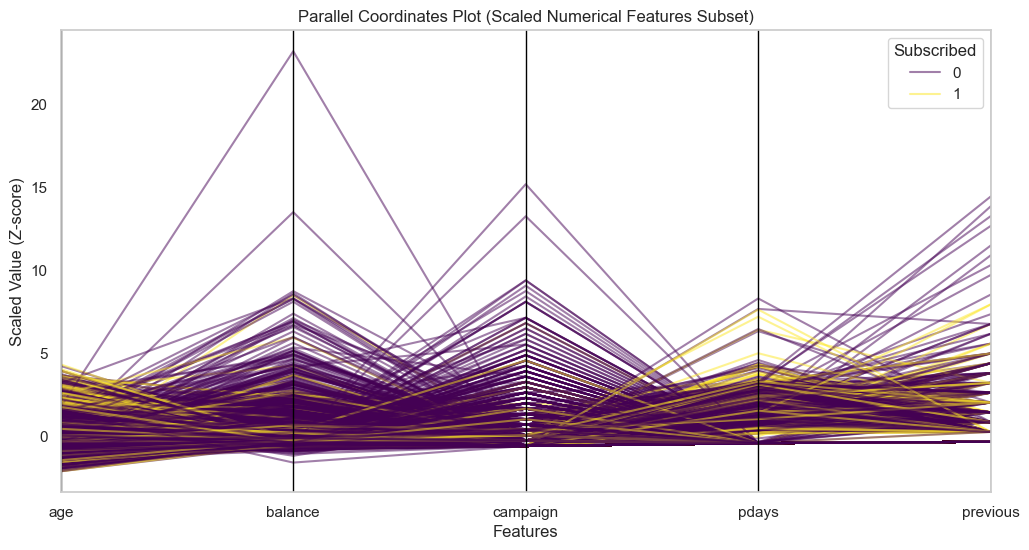

In [9]:
from pandas.plotting import parallel_coordinates


features_for_parallel_plot = ["age", "balance", "campaign", "pdays", "previous"]
indices_for_plot = [
    feature_names_processed.index(f)
    for f in features_for_parallel_plot
    if f in feature_names_processed
]
names_for_plot = [f for f in features_for_parallel_plot if f in feature_names_processed]

parallel_df = pd.DataFrame(X_processed[:, indices_for_plot], columns=names_for_plot)
parallel_df["Target"] = y_processed  # Colouring by target

# You can uncomment this, to make the plot less cluttered
# parallel_df_sample = parallel_df.sample(n=500, random_state=42) if len(parallel_df) > 500 else parallel_df
parallel_df_sample = parallel_df

plt.figure(figsize=(12, 6))
parallel_coordinates(parallel_df_sample, "Target", colormap="viridis", alpha=0.5)

plt.title("Parallel Coordinates Plot (Scaled Numerical Features Subset)")
plt.xlabel("Features")
plt.ylabel("Scaled Value (Z-score)")
plt.legend(title="Subscribed", loc="upper right")
plt.grid(False)
plt.show()

*Examine the Parallel Coordinates plot. Look for patterns: Do lines belonging to the 'Yes' class (often yellow/green with 'viridis' map) tend to follow different paths across certain axes compared to the 'No' class (purple/blue)?   
For instance, do subscribers tend to have lower 'pdays' (more recent contact, closer to the bottom of the scaled axis if negative values are lowest) or higher 'previous' contacts (closer to the top of that axis)? This plot helps visualise such multivariate relationships and potential separators.*